In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import uproot
from matplotlib.patches import Rectangle
from torch.utils.data import Dataset

from analysis.utils.geometry import Geometry, get_rebinned_geometry
# from analysis.utils.truth import TruthParticle

In [2]:
input_path = Path(
    # "/Users/tboeckh/Documents/faser/neutrino-detector/Pinpoint_G4/analysis/src/analysis/data/pinpoint.root"
    "/Users/tboeckh/tmp/pinpoint.root"
)

## Create parquet files


In [3]:
root_file = uproot.open(input_path)

# truth neutrino
truth_columns = ["evtID", "initPDG", "initX", "initY", "initZ", "initE"]
truth_df = root_file["event"].arrays(truth_columns, library="pd")
truth_df.rename(
    columns={
        "evtID": "event_id",
        "initPDG": "pdg_nu",
        "initE": "E_nu",
        "initX": "x",
        "initY": "y",
        "initZ": "z",
    },
    inplace=True,
)

# truth lepton
primaries_columns = ["evtID", "trackID", "PDG", "E"]
primaries_df = root_file["primaries"].arrays(primaries_columns, library="pd")
primaries_df.query("trackID == 1", inplace=True)
primaries_df = primaries_df[[i for i in primaries_df.columns if i != "trackID"]]
primaries_df.rename(
    columns={"evtID": "event_id", "E": "E_lepton", "PDG": "pdg_lepton"},
    inplace=True,
)

if len(truth_df) != len(primaries_df):
    raise ValueError("Dataframes should have same length!")

truth_df = pd.merge(truth_df, primaries_df, left_on="event_id", right_on="event_id")
truth_df.head()

,event_id,pdg_nu,x,y,z,E_nu,pdg_lepton,E_lepton
0,4000,14,-6.694495,-6.073128,40.698491,2013300.0,14,925076.562500
1,4001,-14,-75.513086,-25.472141,41.622013,420690.0,-14,252249.750000
2,4002,14,38.405663,-23.206660,41.183092,669180.0,14,193179.984375
3,4003,14,-81.015595,-89.752868,41.837095,139710.0,14,93055.640625
4,4004,14,52.548819,44.859072,42.397451,409710.0,14,142692.906250


In [4]:
# geometry
geom_columns = ["pixel_Xpos", "pixel_Ypos", "pixel_Zpos"]
geom = root_file["geometry"].arrays(geom_columns, library="np")

# pixel hits
columns = ["event_id", "hit_rowID", "hit_colID", "hit_layerID"]
df: pd.DataFrame = ak.to_dataframe(
    root_file["Hits/pixelHits"].arrays(columns, library="ak"),
    how="outer",
)

# remove hits that are outside of the detector range
max_row_index = 8596
max_col_index = 12788
df.query(f"hit_rowID < {max_row_index} and hit_colID < {max_col_index}", inplace=True)

# map pixel indices to positions
df.loc[:, "x"] = geom["pixel_Xpos"][0][df["hit_colID"].astype(int).values]
df.loc[:, "y"] = geom["pixel_Ypos"][0][df["hit_rowID"].astype(int).values]
df.loc[:, "z"] = geom["pixel_Zpos"][0][df["hit_layerID"].astype(int).values]

df.head()

event_id  hit_rowID  hit_colID  hit_layerID       x       y  \
entry subentry                                                                
0     0             4000     4065.0     6106.0          3.0 -5.9848 -5.3066   
      1             4000     4505.0     6378.0          5.0 -0.3272  4.7254   
      2             4000     4534.0     6333.0          5.0 -1.2632  5.3866   
      3             4000     4010.0     6298.0          5.0 -1.9912 -6.5606   
      4             4000     4038.0     6464.0          6.0  1.4616 -5.9222   

                     z  
entry subentry          
0     0         40.035  
      1         60.055  
      2         60.055  
      3         60.055  
      4         70.065

In [5]:
# map pixel indices to positions
# df["x"] = df.apply(lambda row: geom["pixel_Xpos"][0][int(row["hit_colID"])], axis=1)
# df["y"] = df.apply(lambda row: geom["pixel_Ypos"][0][int(row["hit_rowID"])], axis=1)
# df["z"] = df.apply(lambda row: geom["pixel_Zpos"][0][int(row["hit_layerID"])], axis=1)

df.loc[:, "x"] = geom["pixel_Xpos"][0][df["hit_colID"].astype(int).values]
df.loc[:, "y"] = geom["pixel_Ypos"][0][df["hit_rowID"].astype(int).values]
df.loc[:, "z"] = geom["pixel_Zpos"][0][df["hit_layerID"].astype(int).values]

df.head()

event_id  hit_rowID  hit_colID  hit_layerID       x       y  \
entry subentry                                                                
0     0             4000     4065.0     6106.0          3.0 -5.9848 -5.3066   
      1             4000     4505.0     6378.0          5.0 -0.3272  4.7254   
      2             4000     4534.0     6333.0          5.0 -1.2632  5.3866   
      3             4000     4010.0     6298.0          5.0 -1.9912 -6.5606   
      4             4000     4038.0     6464.0          6.0  1.4616 -5.9222   

                     z  
entry subentry          
0     0         40.035  
      1         60.055  
      2         60.055  
      3         60.055  
      4         70.065

In [6]:
from analysis.utils.geometry import Geometry

In [7]:
geom = root_file["geometry"].arrays(library="np")

In [ ]:
from analysis.utils.geometry import Geometry
from analysis.utils.units import mm, um

In [66]:
geo = Geometry(
    pixel_x_size=20.8 * um,
    pixel_y_size=22.8 * um,
    num_x_pixels=12788,
    num_y_pixels=8596,
    num_layers=149,
    tungsten_thickness=5 * mm,
    silicon_thickness=10 * um,
)

In [67]:
geo.get_x_pos(1000)

-112.19520000000001

In [68]:
geom.keys()

dict_keys(['detector_width', 'detector_height', 'tungsten_thickness', 'silicon_thickness', 'nLayers', 'pixel_Xpos', 'pixel_Ypos', 'pixel_Zpos', 'sim_flag', 'scint_bar_flag'])

In [69]:
geom

{'detector_width': array([266.], dtype=float32),
 'detector_height': array([196.], dtype=float32),
 'tungsten_thickness': array([5.], dtype=float32),
 'silicon_thickness': array([10.], dtype=float32),
 'nLayers': array([149], dtype=int32),
 'pixel_Xpos': array([array([-132.9896, -132.9688, -132.948 , ...,  132.9384,  132.9592,
                132.98  ], shape=(12788,))                                ],
       dtype=object),
 'pixel_Ypos': array([array([-97.9886, -97.9658, -97.943 , ...,  97.9318,  97.9546,  97.9774],
              shape=(8596,))                                                    ],
       dtype=object),
 'pixel_Zpos': array([array([  10.005,   20.015,   30.025,   40.035,   50.045,   60.055,
                 70.065,   80.075,   90.085,  100.095,  110.105,  120.115,
                130.125,  140.135,  150.145,  160.155,  170.165,  180.175,
                190.185,  200.195,  210.205,  220.215,  230.225,  240.235,
                250.245,  260.255,  270.265,  280.275,  29

In [70]:
geom["pixel_Xpos"][0][1000]

np.float64(-112.1896)

In [71]:
len(geom["pixel_Xpos"][0])

12788

In [72]:
layer_thickness = geom["pixel_Zpos"][0][1] - geom["pixel_Zpos"][0][0]

In [ ]:
256 * 0.200

51.2

In [75]:
df.head()

event_id  hit_rowID  hit_colID  hit_layerID       x       y  \
entry subentry                                                                
0     0             4000     4065.0     6106.0          3.0 -5.9848 -5.3066   
      1             4000     4505.0     6378.0          5.0 -0.3272  4.7254   
      2             4000     4534.0     6333.0          5.0 -1.2632  5.3866   
      3             4000     4010.0     6298.0          5.0 -1.9912 -6.5606   
      4             4000     4038.0     6464.0          6.0  1.4616 -5.9222   

                     z  
entry subentry          
0     0         40.035  
      1         60.055  
      2         60.055  
      3         60.055  
      4         70.065

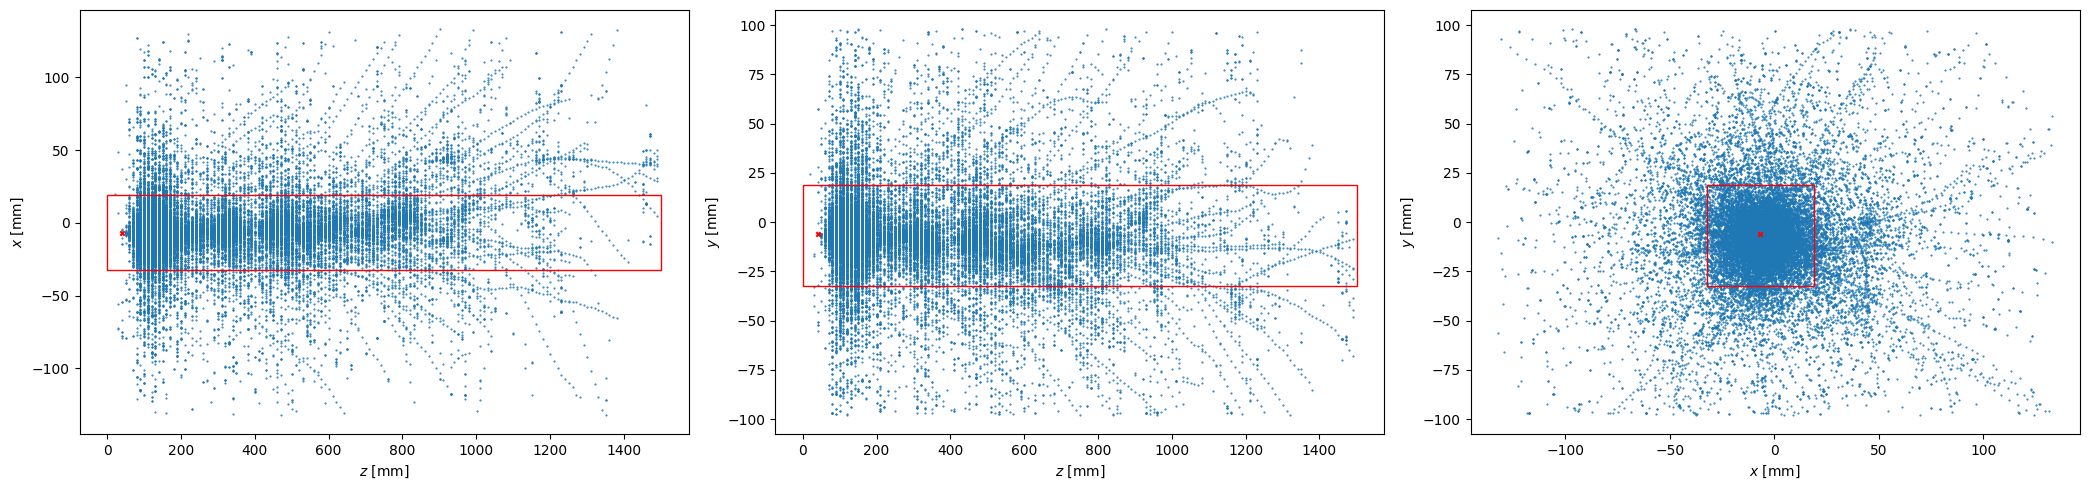

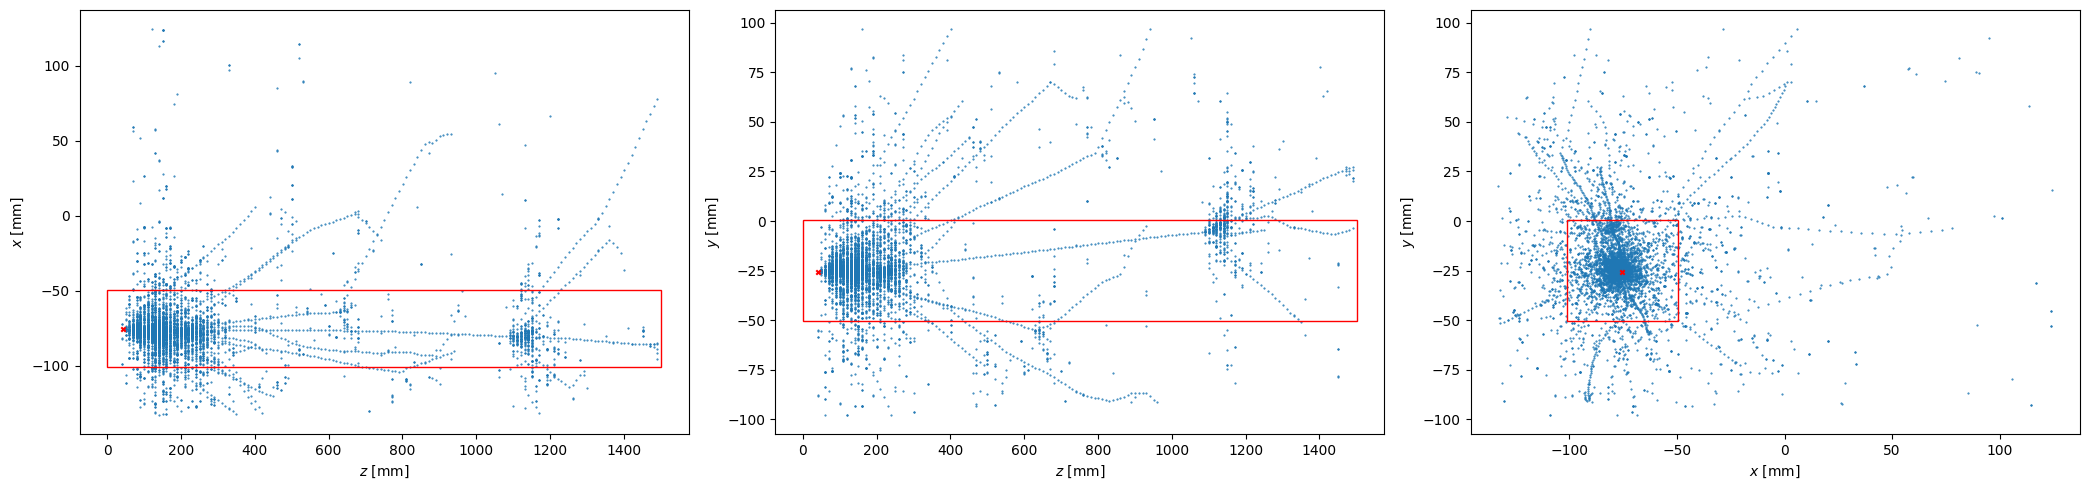

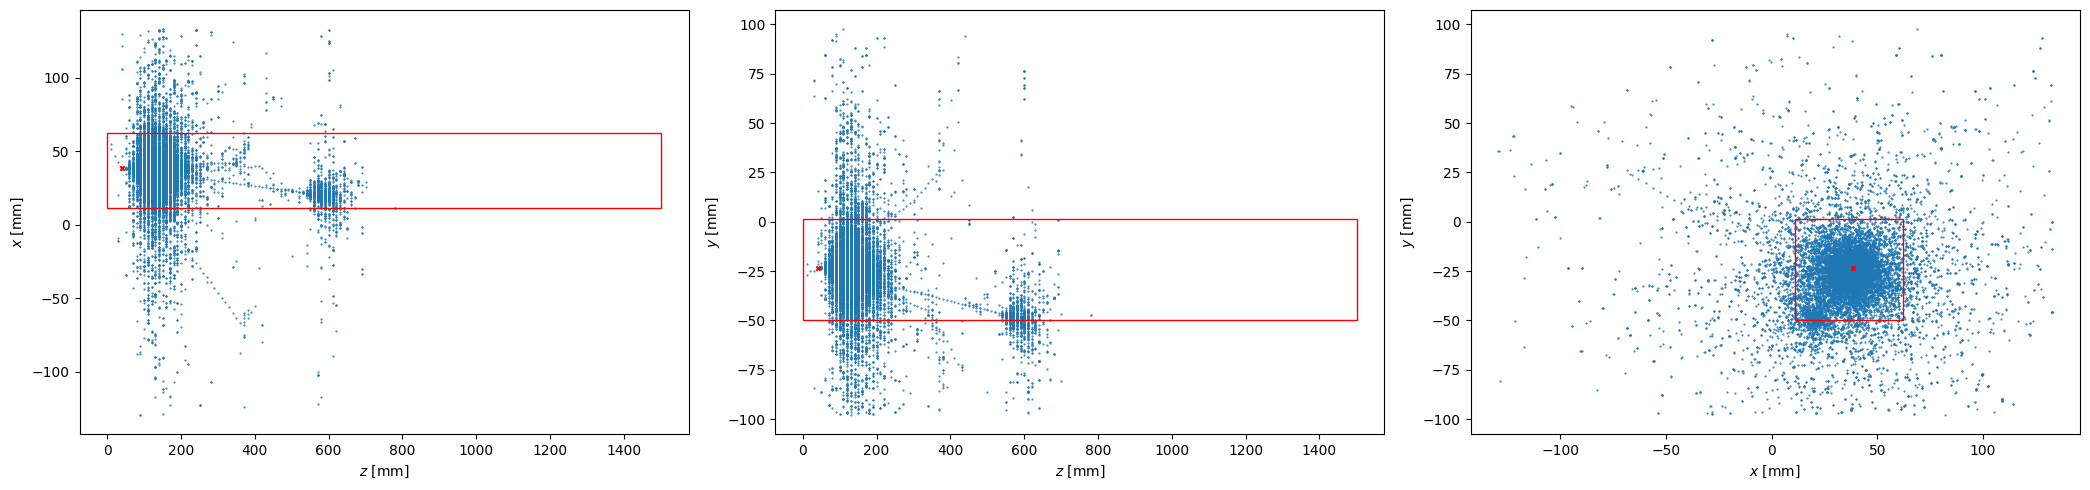

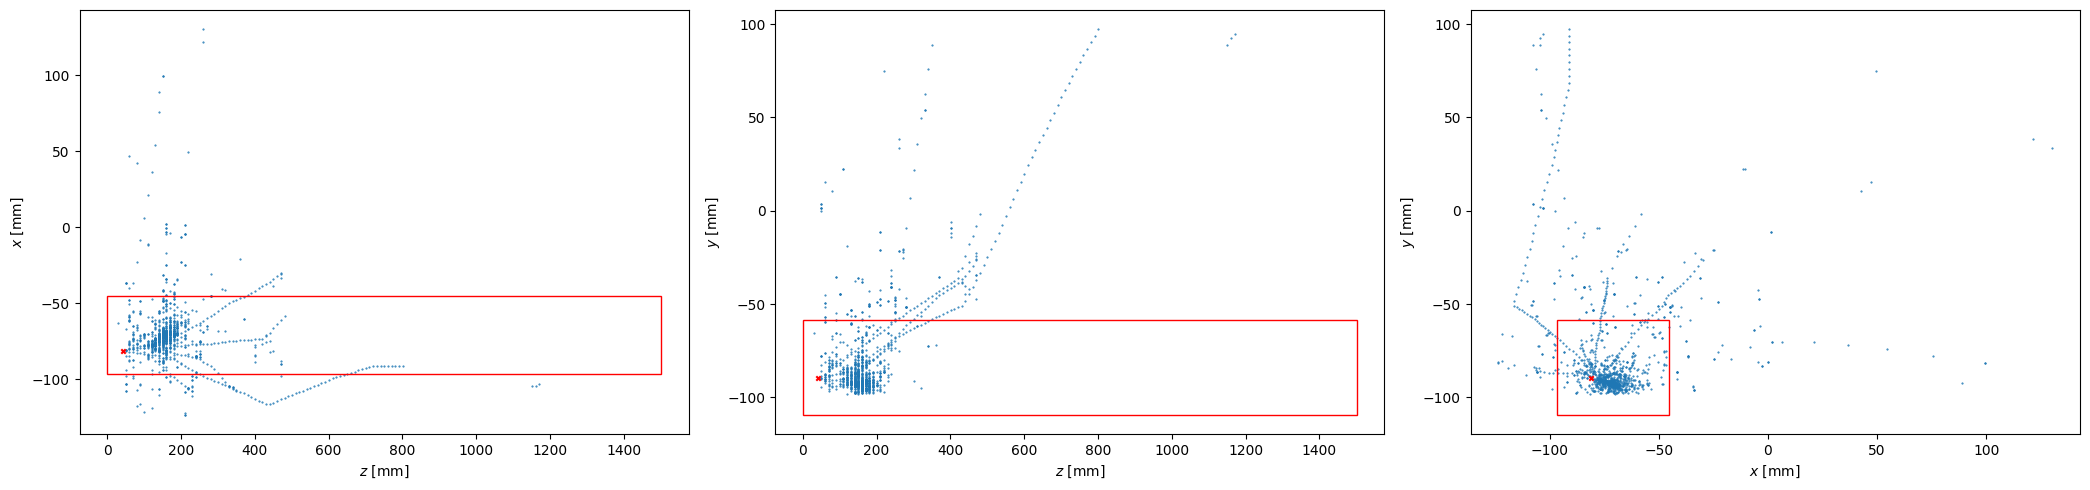

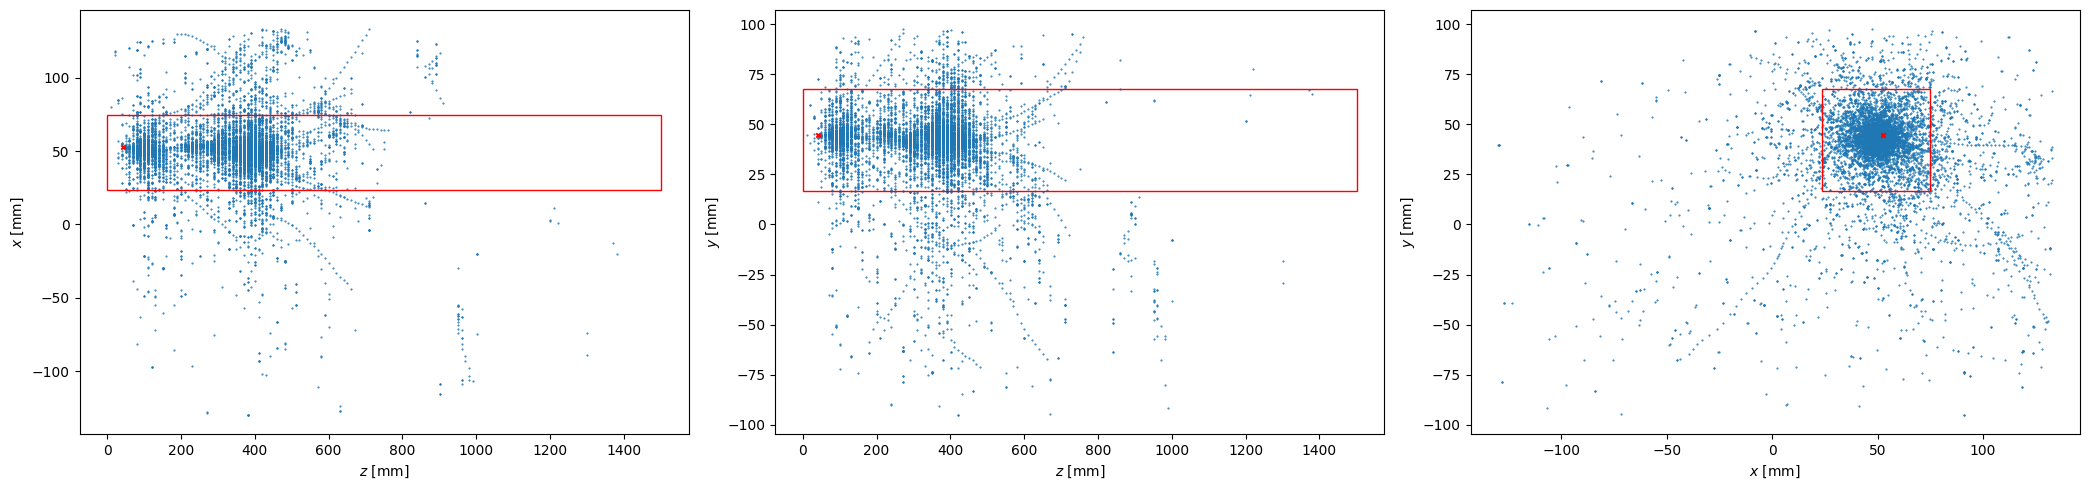

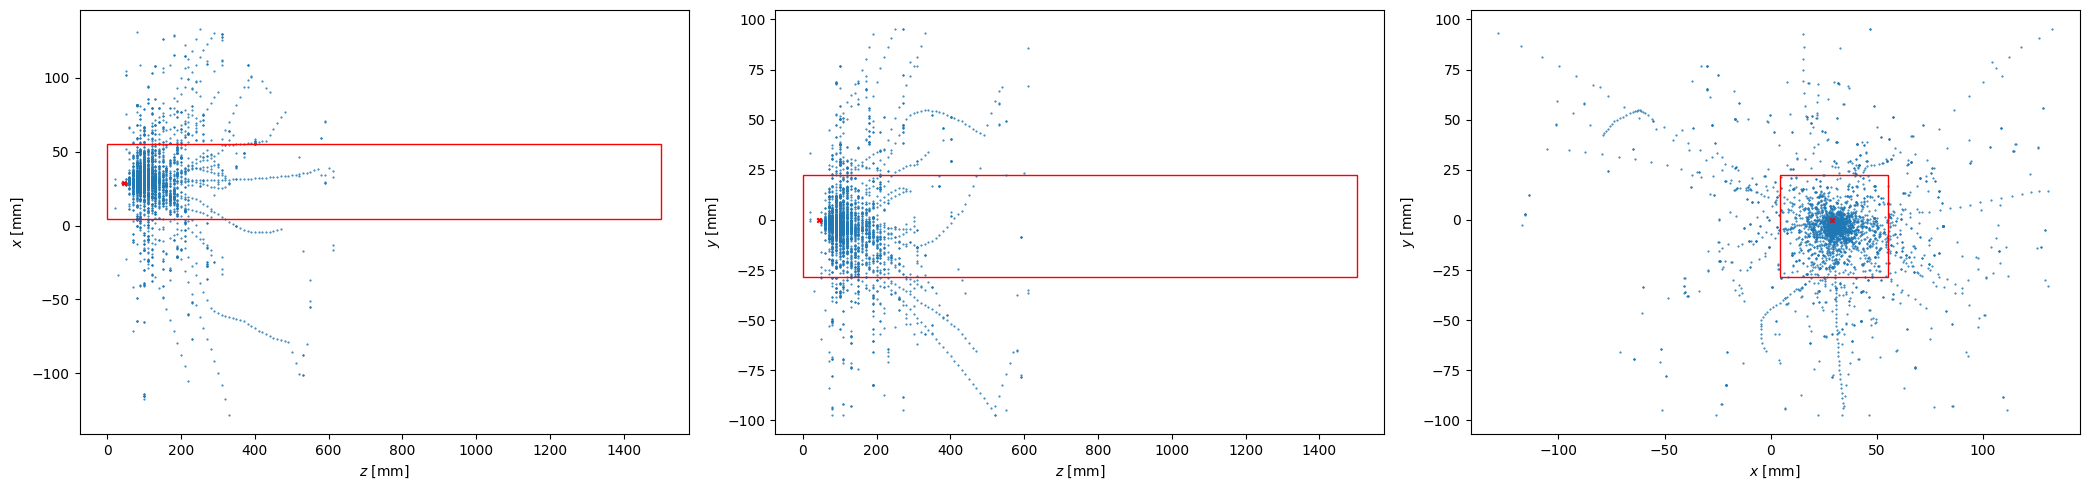

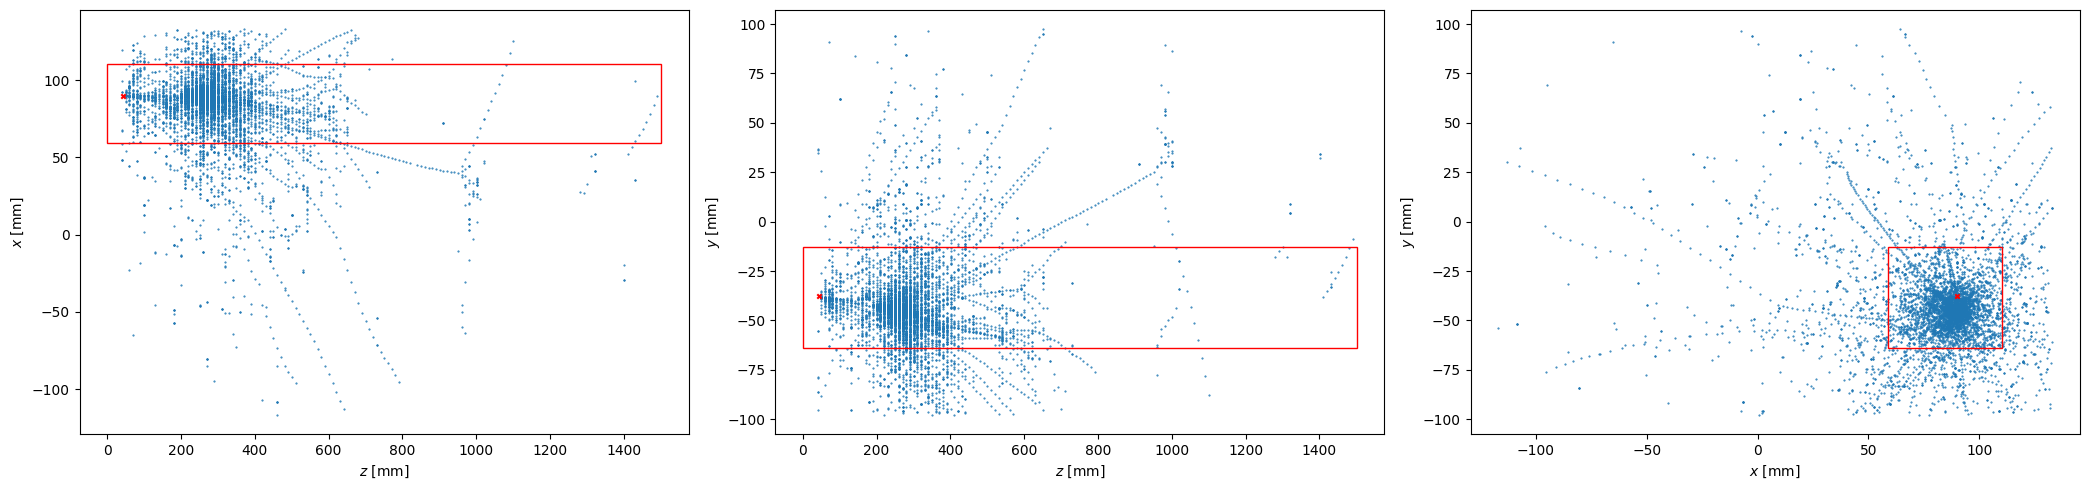

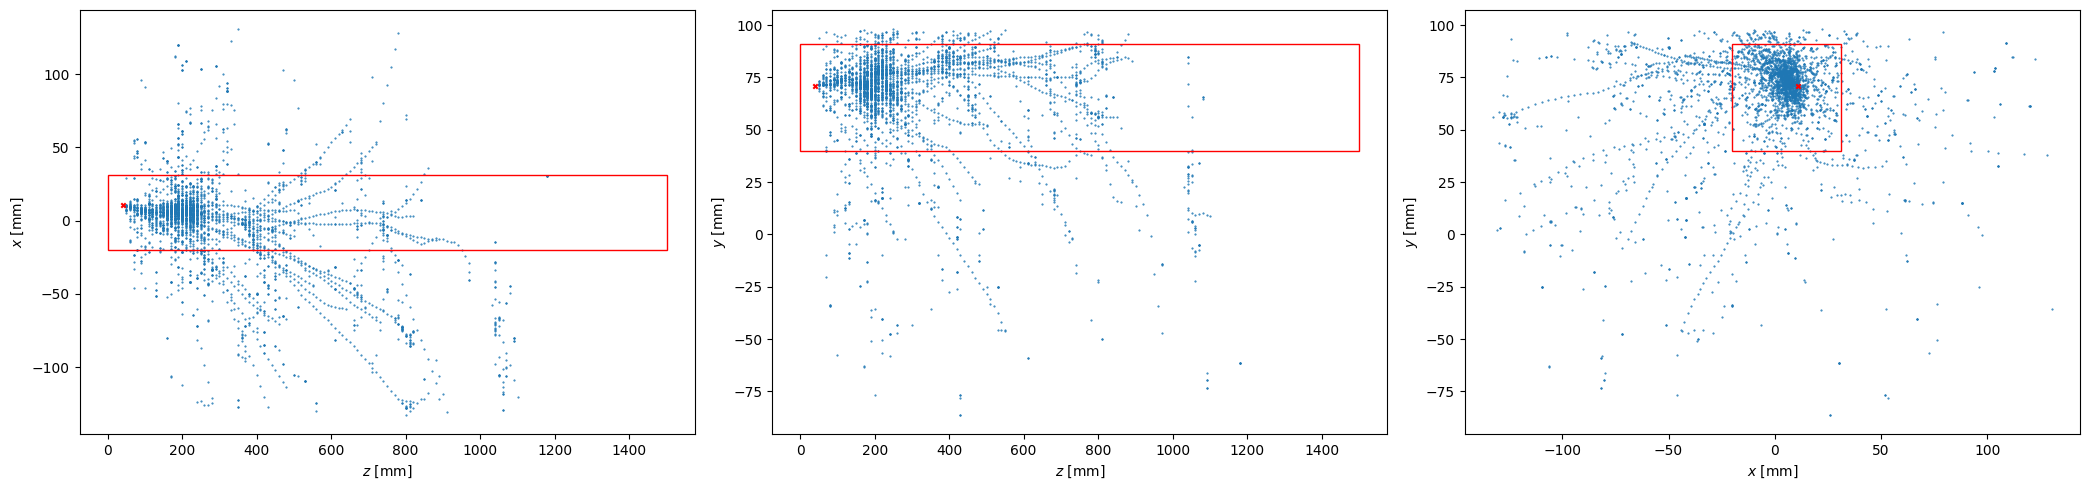

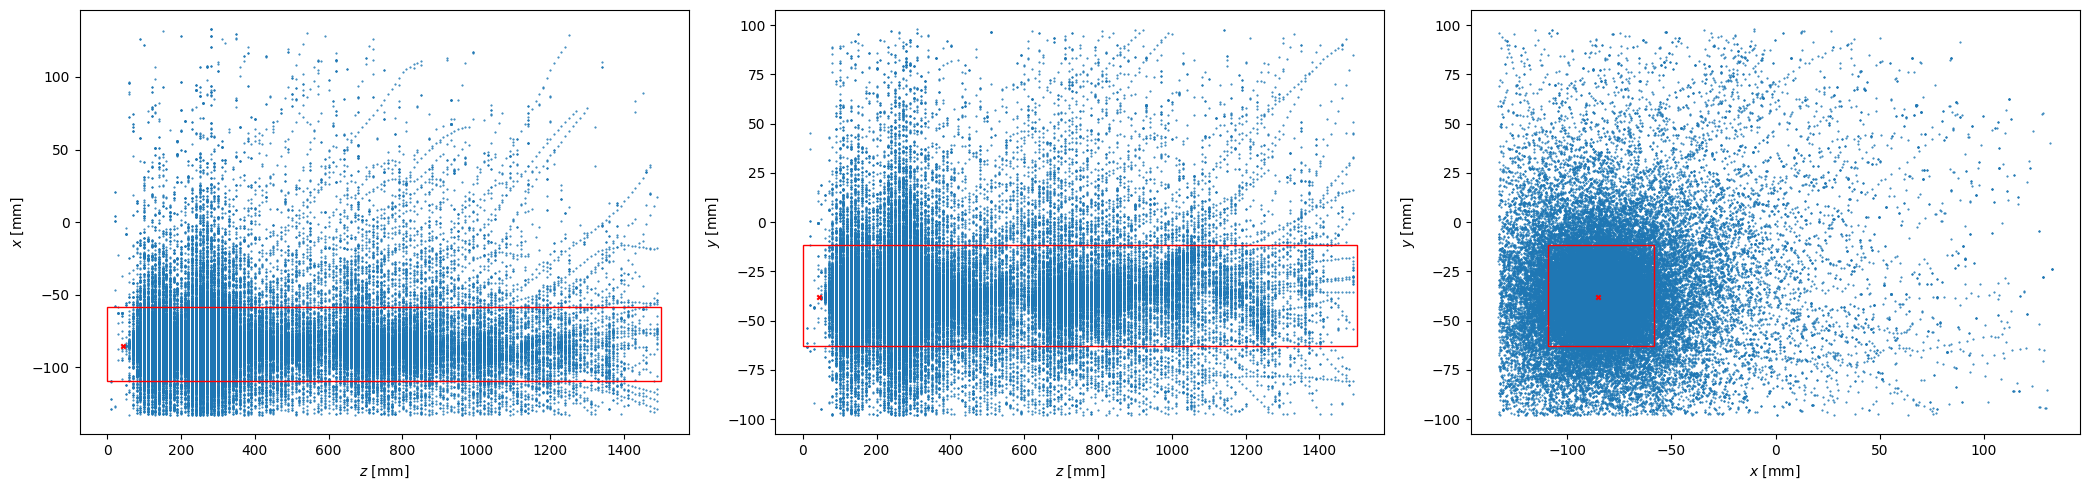

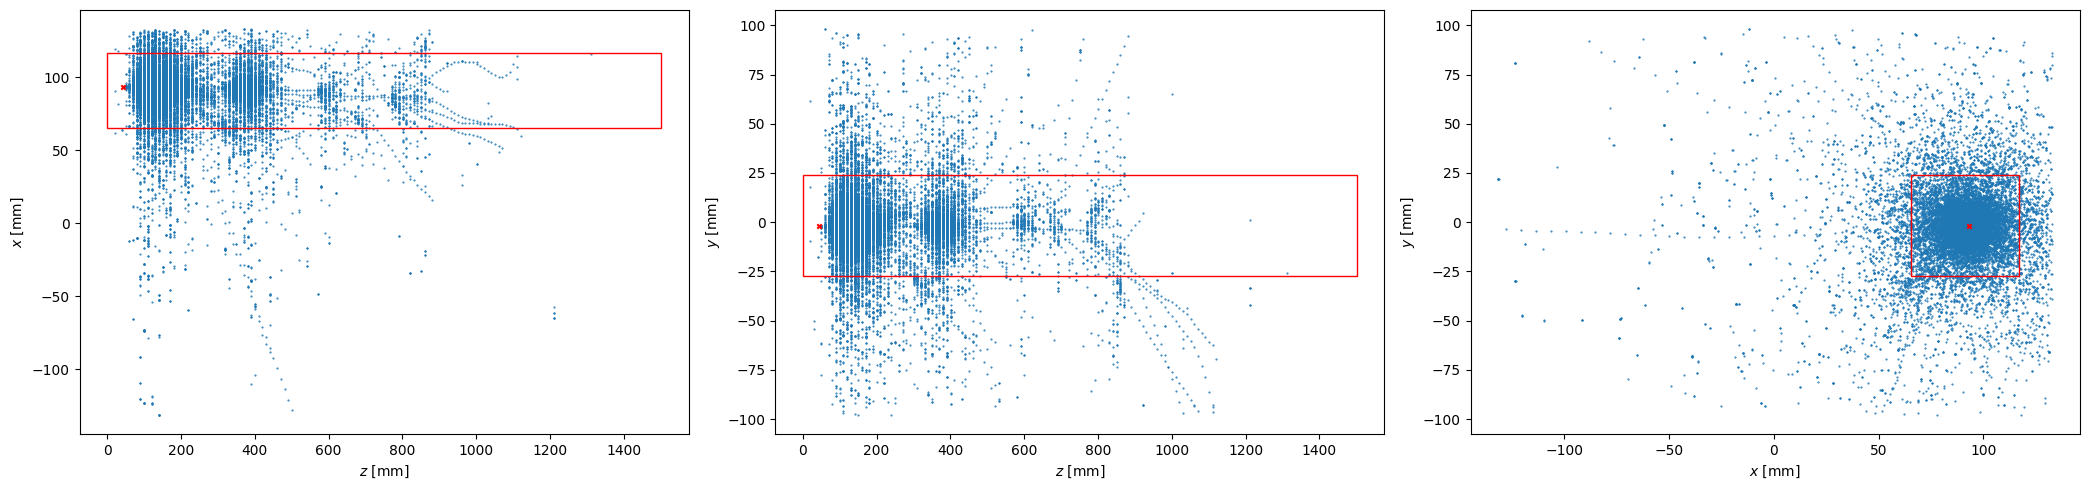

In [76]:
window_size = 51.2  # mm


for event_id in range(10):
    event_df = df.query(f"event_id == 4000 + {event_id}")
    event_truth_df = truth_df.query(f"event_id == 4000 + {event_id}")

    mean_x, mean_y = (
        event_df.query("hit_layerID >= 4 & hit_layerID <= 14")[["x", "y"]].mean().values
    )
    # print("truth: ", event_truth_df[["x", "y"]].values)

    fig, ax = plt.subplots(ncols=3, figsize=(21, 5))
    # zx
    ax[0].scatter(event_df["z"], event_df["x"], marker=".", s=1)
    ax[0].scatter(event_truth_df["z"], event_truth_df["x"], c="red", marker="x", s=10)
    ax[0].set_xlabel(r"$z$ [mm]")
    ax[0].set_ylabel(r"$x$ [mm]")
    ax[0].add_patch(
        Rectangle(
            (0, mean_x - window_size / 2),
            150 * layer_thickness,
            window_size,
            linewidth=1,
            edgecolor="r",
            facecolor="none",
        )
    )

    # zy
    ax[1].scatter(event_df["z"], event_df["y"], marker=".", s=1)
    ax[1].scatter(event_truth_df["z"], event_truth_df["y"], c="red", marker="x", s=10)
    ax[1].set_xlabel(r"$z$ [mm]")
    ax[1].set_ylabel(r"$y$ [mm]")
    ax[1].add_patch(
        Rectangle(
            (0, mean_y - window_size / 2),
            150 * layer_thickness,
            window_size,
            linewidth=1,
            edgecolor="r",
            facecolor="none",
        )
    )

    # xy
    ax[2].scatter(event_df["x"], event_df["y"], marker=".", s=1)
    ax[2].scatter(event_truth_df["x"], event_truth_df["y"], c="red", marker="x", s=10)
    ax[2].set_xlabel(r"$x$ [mm]")
    ax[2].set_ylabel(r"$y$ [mm]")
    ax[2].add_patch(
        Rectangle(
            (mean_x - window_size / 2, mean_y - window_size / 2),
            window_size,
            window_size,
            linewidth=1,
            edgecolor="r",
            facecolor="none",
        )
    )

    plt.tight_layout()
    plt.show()

## Create torch files


In [ ]:
import hist
import matplotlib as mpl
import mplhep

from analysis.utils.truth import TruthParticle, get_truth_particle

In [32]:
df = pd.read_parquet("/Users/tboeckh/tmp/10000_1_hits.parq")
truth_df = pd.read_parquet("/Users/tboeckh/tmp/10000_1_truth.parq")

In [55]:
df.head()

,event_id,hit_layerID,pixel_x,pixel_y,energy,n_hits
0,1000,3,66,63,0.006147,2
1,1000,3,78,65,0.008508,1
2,1000,3,141,85,0.004021,1
3,1000,4,1,150,0.033051,2
4,1000,4,20,79,0.004250,1


In [33]:
truth_df.head()

,event_id,pdg_nu,vx,vy,vz,E_nu,pdg_lepton,E_lepton,px_lepton,py_lepton,pz_lepton
0,1000,12,-120.019833,-50.208872,42.887959,185100.0,11,5.086507e+04,-686.625977,6618.303223,5.042799e+04
1,1001,12,39.117342,-82.877938,43.200977,766650.0,11,3.284916e+05,-1516.706299,-2198.088623,3.284808e+05
2,1002,-12,66.572006,63.753465,43.155907,816280.0,-11,6.666709e+05,798.447144,-3059.814209,6.666634e+05
3,1003,12,83.249276,36.725500,41.372620,1835700.0,11,1.647914e+06,-9069.093750,-2104.084229,1.647888e+06
4,1004,12,28.462527,-58.525877,44.768412,270080.0,11,1.961442e+05,-5070.404297,-3358.842773,1.960499e+05


In [51]:
df.head()

,event_id,hit_layerID,pixel_x,pixel_y,energy,n_hits
0,1000,3,66,63,0.006147,2
1,1000,3,78,65,0.008508,1
2,1000,3,141,85,0.004021,1
3,1000,4,1,150,0.033051,2
4,1000,4,20,79,0.004250,1


In [50]:
truth_df.query("event_id == 1000").iloc[0]

event_id        1000.000000
pdg_nu            12.000000
vx              -120.019833
vy               -50.208872
vz                42.887959
E_nu          185100.000000
pdg_lepton        11.000000
E_lepton       50865.070312
px_lepton       -686.625977
py_lepton       6618.303223
pz_lepton      50427.988281
Name: 0, dtype: float64

mean x, y:  34.1540173603383 97.61139550411751


/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_8616/1197301470.py:22: UserWarning: Please use 'Weight()' instead of 'Weight'
  h = hist.Hist(
/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_8616/1197301470.py:38: UserWarning: Please use 'Weight()' instead of 'Weight'
  h = hist.Hist(


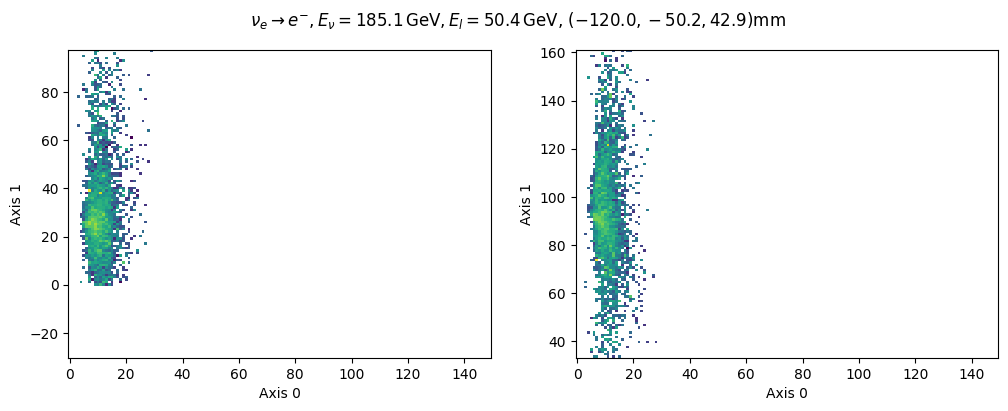

In [39]:
event_id = 1000
num_layers = 150

for i in range(1):
    new_event_df = df.query(f"event_id == {event_id + i}")
    # truth = TruthParticle(truth_df.query(f"event_id == {event_id + i}"))
    truth = get_truth_particle(truth_df.query("event_id == 1000"))

    mean_x, mean_y = (
        new_event_df.query("hit_layerID >= 4 & hit_layerID <= 14")[
            ["pixel_x", "pixel_y"]
        ]
        .mean()
        .values
    )
    print("mean x, y: ", mean_x, mean_y)
    # print("truth: ", event_truth_df[["x", "y"]].values)

    fig, ax = plt.subplots(1, 2, figsize=(2 * 6, 4))

    # zx
    h = hist.Hist(
        hist.axis.Variable(np.arange(-0.5, num_layers + 0.5, 1)),
        hist.axis.Variable(np.arange(mean_x - 64.5, mean_x + 64.5, 1)),
        # hist.axis.Variable(np.arange(-0.5, new_geo.num_x_pixels + 0.5, 1)),
        storage=hist.storage.Weight,
    )
    h.fill(
        new_event_df["hit_layerID"],
        new_event_df["pixel_x"],
        weight=new_event_df["energy"],
    )
    mplhep.hist2dplot(
        h, cmap="viridis", norm=mpl.colors.LogNorm(), cbar=False, ax=ax[0], flow=False
    )

    # zy
    h = hist.Hist(
        hist.axis.Variable(np.arange(-0.5, num_layers + 0.5, 1)),
        hist.axis.Variable(np.arange(mean_y - 64.5, mean_y + 64.5, 1)),
        # hist.axis.Variable(np.arange(-0.5, new_geo.num_y_pixels + 0.5, 1)),
        storage=hist.storage.Weight,
    )
    h.fill(
        new_event_df["hit_layerID"],
        new_event_df["pixel_y"],
        weight=new_event_df["energy"],
    )
    mplhep.hist2dplot(
        h, cmap="viridis", norm=mpl.colors.LogNorm(), cbar=False, ax=ax[1], flow=False
    )
    plt.suptitle(truth.get_latex_title())
    plt.show()

In [ ]:
def create_voxels(
    hits_df: pd.DataFrame,
    bins: tuple[int, int, int] = (128, 128, 200),
    layer_var: str = "hit_layerID",
) -> tuple[int, int, np.ndarray]:
    if len(hits_df) == 0:
        return 0, 0, np.zeros(bins)

    x_half_size = bins[0] // 2
    y_half_size = bins[1] // 2

    mean_x, mean_y = (
        hits_df.query(f"{layer_var} >= 4 & {layer_var} <= 14")[["x", "y"]]
        .mean()
        .astype(int)
        .values
    )

    x_min, x_max = mean_x - x_half_size, mean_x + x_half_size
    y_min, y_max = mean_y - y_half_size, mean_y + y_half_size

    h = hist.Hist(
        hist.axis.Variable(np.arange(x_min - 0.5, x_max + 0.5, 1)),  # x pixel axis
        hist.axis.Variable(np.arange(y_min - 0.5, y_max + 0.5, 1)),  # y pixel axis
        hist.axis.Variable(np.arange(-0.5, bins[2] + 0.5, 1)),  # layer axis
        storage=hist.storage.Weight(),
    )
    h.fill(
        hits_df["pixel_x"],
        hits_df["pixel_y"],
        hits_df[layer_var],
        weight=hits_df["n_hits"],
    )
    voxels = h.values()
    if voxels.shape != bins:
        raise ValueError(f"Voxel shape {voxels.shape} does not match expected {bins}")
    return mean_x, mean_y, voxels

In [52]:
def create_projections(
    hits_df: pd.DataFrame,
    bins: tuple[int, int, int] = (128, 150),
    layer_var: str = "hit_layerID",
) -> tuple[int, int, np.ndarray, np.ndarray]:
    if len(hits_df) == 0:
        return 0, 0, np.zeros(bins)

    x_half_size = bins[0] // 2
    y_half_size = bins[1] // 2

    mean_x, mean_y = (
        hits_df.query(f"{layer_var} >= 4 & {layer_var} <= 14")[["x", "y"]]
        .mean()
        .astype(int)
        .values
    )

    x_min, x_max = mean_x - x_half_size, mean_x + x_half_size
    y_min, y_max = mean_y - y_half_size, mean_y + y_half_size

    h_zx = hist.Hist(
        hist.axis.Variable(np.arange(-0.5, bins[2] + 0.5, 1)),  # layer axis
        hist.axis.Variable(np.arange(x_min - 0.5, x_max + 0.5, 1)),  # x pixel axis
        storage=hist.storage.Weight(),
    )

    h_zy = hist.Hist(
        hist.axis.Variable(np.arange(-0.5, bins[2] + 0.5, 1)),  # layer axis
        hist.axis.Variable(np.arange(y_min - 0.5, y_max + 0.5, 1)),  # y pixel axis
        storage=hist.storage.Weight(),
    )

    h_zx.fill(hits_df[layer_var], hits_df["pixel_x"], weight=hits_df["n_hits"])
    h_zy.fill(hits_df[layer_var], hits_df["pixel_y"], weight=hits_df["n_hits"])

    zx_projection = h_zx.values()
    zy_projection = h_zy.values()

    return mean_x, mean_y, zx_projection, zy_projection

In [53]:
class CNNProjectionDataset(Dataset):
    """Dataset that stores binned pixel counts per event"""

    def __init__(
        self,
        data_list: list[tuple[pd.DataFrame, pd.DataFrame, int]],
        bins: tuple[int, int, int],
        geo: Geometry,
    ):
        self.projections = []
        self.labels = []
        self.e_nu = []
        self.e_lepton = []
        self.vx = []
        self.vy = []
        self.delta_vx = []
        self.delta_vy = []

        for hits_df, truth_df, label in data_list:
            event_ids = hits_df["event_id"].unique()
            print(f"Processing {len(event_ids)} events")

            for event_id in event_ids:
                event_hits = hits_df.loc[hits_df["event_id"] == event_id]
                event_truth = truth_df[truth_df["event_id"] == event_id].iloc[0]
                if len(event_truth) != 1:
                    print(
                        f"Warning: Expected exactly one row, "
                        f"but got {len(event_truth)}, skipping event {event_id}."
                    )
                    continue

                mean_x, mean_y, zx_proj, zy_proj = create_projections(event_hits, bins)

                zx_tensor = torch.FloatTensor(zx_proj).unsqueeze(0)
                zx_tensor = torch.log(zx_tensor + 1)

                zy_tensor = torch.FloatTensor(zy_proj).unsqueeze(0)
                zy_tensor = torch.log(zy_tensor + 1)

                self.projections.append((zx_tensor, zy_tensor))

                # truth variables
                self.labels.append(label)
                self.e_nu.append(np.float32(event_truth["E_nu"]))
                self.e_lepton.append(np.float32(event_truth["E_lepton"]))

                vx = np.float32(event_truth["vx"])
                vy = np.float32(event_truth["vy"])
                mean_x_pos = geo.get_x_pos(mean_x)
                mean_y_pos = geo.get_y_pos(mean_y)
                self.vx.append(vx)
                self.vy.append(vy)
                self.delta_vx.append(mean_x_pos - vx)
                self.delta_vy.append(mean_y_pos - vy)

        print(f"Created dataset with {len(self.projections)} samples")

    def __len__(self):
        return len(self.projections)

    def __getitem__(self, idx):
        zx_tensor, zy_tensor = self.projections[idx]
        targets = {
            "label": self.labels[idx],
            "E_nu": np.float32(self.e_nu[idx]),
            "E_lepton": np.float32(self.e_lepton[idx]),
            "delta_vx": np.float32(self.delta_vx[idx]),
            "delta_vy": np.float32(self.delta_vy[idx]),
            "vx": np.float32(self.vx[idx]),
            "vy": np.float32(self.vy[idx]),
        }

        return (zx_tensor, zy_tensor), targets

In [ ]:
class CNN3DDataset(Dataset):
    """Dataset that stores binned pixel counts per event"""

    def __init__(
        self,
        data_list: list[tuple[pd.DataFrame, pd.DataFrame, int]],
        bins: tuple[int, int, int],
        geo: Geometry,
    ):
        self.voxels = []
        self.labels = []
        self.e_nu = []
        self.e_lepton = []
        self.vx = []
        self.vy = []
        self.delta_vx = []
        self.delta_vy = []

        for hits_df, truth_df, label in data_list:
            event_ids = hits_df["event_id"].unique()
            print(f"Processing {len(event_ids)} events")

            for event_id in event_ids:
                event_hits = hits_df.loc[hits_df["event_id"] == event_id]
                event_truth = truth_df[truth_df["event_id"] == event_id].iloc[0]
                if len(event_truth) != 1:
                    print(
                        f"Warning: Expected exactly one row, "
                        f"but got {len(event_truth)}, skipping event {event_id}."
                    )
                    continue

                mean_x, mean_y, voxel_data = create_voxels(event_hits, bins)

                voxel_tensor = torch.FloatTensor(voxel_data).unsqueeze(0)
                voxel_tensor = torch.log(voxel_tensor + 1)
                self.voxels.append(voxel_tensor)

                # truth variables
                self.labels.append(label)
                self.e_nu.append(np.float32(event_truth["E_nu"]))
                self.e_lepton.append(np.float32(event_truth["E_lepton"]))

                vx = np.float32(event_truth["vx"])
                vy = np.float32(event_truth["vy"])
                mean_x_pos = geo.get_x_pos(mean_x)
                mean_y_pos = geo.get_y_pos(mean_y)
                self.vx.append(vx)
                self.vy.append(vy)
                self.delta_vx.append(mean_x_pos - vx)
                self.delta_vy.append(mean_y_pos - vy)

        print(f"Created dataset with {len(self.voxels)} samples")

    def __len__(self):
        return len(self.voxels)

    def __getitem__(self, idx):
        voxel_tensor = self.voxels[idx]
        targets = {
            "label": self.labels[idx],
            "E_nu": np.float32(self.e_nu[idx]),
            "E_lepton": np.float32(self.e_lepton[idx]),
            "delta_vx": np.float32(self.delta_vx[idx]),
            "delta_vy": np.float32(self.delta_vy[idx]),
            "vx": np.float32(self.vx[idx]),
            "vy": np.float32(self.vy[idx]),
        }

        return voxel_tensor, targets

In [ ]:
num_events: int = 5
if num_events is not None:
    num_hits_df = num_hits_df[num_hits_df["event_id"] < num_events]
    num_truth_df = num_truth_df[num_truth_df["event_id"] < num_events]

In [49]:
df

,event_id,hit_layerID,pixel_x,pixel_y,energy,n_hits
0,1000,3,66,63,0.006147,2
1,1000,3,78,65,0.008508,1
2,1000,3,141,85,0.004021,1
3,1000,4,1,150,0.033051,2
4,1000,4,20,79,0.004250,1
...,...,...,...,...,...,...
16260400,1999,61,89,265,0.002891,1
16260401,1999,61,95,284,0.002408,1
16260402,1999,62,47,247,0.005048,1
16260403,1999,86,209,380,0.004727,1


In [ ]:
# def create_3d_dataset_binned(
#     input_path: Path,
#     output_path: Path,
#     bins: Tuple[int, int, int] = (128, 128, 200),
#     num_events: int | None = None,
#     recreate: bool = False,
# ) -> None:
#     # crop_str: str = "_".join([str(i) for i in bins])
#     # binning_str: str = "_".join([str(i) for i in bins])
#     # crop_str: str = "_".join([str(i) for i in bins])
#     dataset_file = output_path / "cnn3d.pt"

#     if dataset_file.exists() and not recreate:
#         print(f"Dataset already exists at {dataset_file}")
#         return

#     output_path.mkdir(parents=True, exist_ok=True)

#     print("Loading data...")
#     nue_hits_df = pd.read_parquet(input_path / "nue_hits.parq")
#     nue_truth_df = pd.read_parquet(input_path / "nue_truth.parq")
#     nue_hits_df, nue_truth_df = select_good_events(
#         nue_hits_df, nue_truth_df, n_min_hits=5
#     )

#     num_hits_df = pd.read_parquet(input_path / "num_hits.parq")
#     num_truth_df = pd.read_parquet(input_path / "num_truth.parq")
#     num_hits_df, num_truth_df = select_good_events(
#         num_hits_df, num_truth_df, n_min_hits=5
#     )

#     nun_hits_df = pd.read_parquet(input_path / "nun_hits.parq")
#     nun_truth_df = pd.read_parquet(input_path / "nun_truth.parq")
#     nun_hits_df, nun_truth_df = select_good_events(
#         nun_hits_df, nun_truth_df, n_min_hits=5
#     )

#     nue_hits_df.query("layer_id < 5")

#     if num_events is not None:
#         nue_hits_df = nue_hits_df[nue_hits_df["event_id"] < num_events]
#         nue_truth_df = nue_truth_df[nue_truth_df["event_id"] < num_events]
#         num_hits_df = num_hits_df[num_hits_df["event_id"] < num_events]
#         num_truth_df = num_truth_df[num_truth_df["event_id"] < num_events]
#         nun_hits_df = nun_hits_df[nun_hits_df["event_id"] < num_events]
#         nun_truth_df = nun_truth_df[nun_truth_df["event_id"] < num_events]

#     print(
#         f"CC num: {len(num_truth_df)} events, {len(num_hits_df)} hits, "
#         f"CC nue: {len(nue_truth_df)} events, {len(nue_hits_df)} hits, "
#         f"NC: {len(nun_truth_df)} events, {len(nun_hits_df)} hits"
#     )

#     hits_data_list = [(nue_hits_df, 0), (num_hits_df, 1), (nun_hits_df, 2)]
#     dataset = Neutrino3DBinnedDataset(hits_data_list, bins=bins)
#     truth_df = pd.concat([nue_truth_df, num_truth_df, nun_truth_df], ignore_index=True)
#     truth_df.to_parquet(output_path / "cnn3d_truth.parq")

#     print(f"Saving dataset to {dataset_file}")
#     torch.save(dataset, dataset_file)